# NB02 - La regresión logística como Modelo Lineal Generalizado

Ahora vemos la regresión logística como un GLM binomial con enlace logit. `statsmodels` permite estudiar deviance, inferencia aproximada, intervalos de confianza y odds ratios.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score

from src.titanic_utils import load_processed_splits, plot_coefficients, set_plot_style

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. El marco GLM

Un GLM separa tres ideas: distribución de la respuesta, predictor lineal y función de enlace. Para Titanic usamos respuesta Bernoulli/binomial, predictor lineal `X beta` y enlace logit.


## 2. Ajuste con statsmodels

`sm.GLM(..., family=sm.families.Binomial())` ajusta por IRLS. No añadimos regularización en este notebook porque el objetivo es la inferencia clásica. La constante se agrega explícitamente con `sm.add_constant`.


In [2]:
X_train_sm = sm.add_constant(X_train, has_constant="add")
X_test_sm = sm.add_constant(X_test, has_constant="add")

glm_model = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial())
glm_result = glm_model.fit()

print(glm_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               survived   No. Observations:                  623
Model:                            GLM   Df Residuals:                      613
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -270.14
Date:                Wed, 17 Jun 2026   Deviance:                       540.28
Time:                        13:29:49   Pearson chi2:                     611.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3715
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6211      0.336      4.828      0.0

In [3]:
conf = glm_result.conf_int()
coef_table = pd.DataFrame(
    {
        "coeficiente": glm_result.params,
        "std_error": glm_result.bse,
        "p_value": glm_result.pvalues,
        "odds_ratio": np.exp(glm_result.params),
        "or_ci_low": np.exp(conf[0]),
        "or_ci_high": np.exp(conf[1]),
    }
)
display(coef_table)


,coeficiente,std_error,p_value,odds_ratio,or_ci_low,or_ci_high
const,1.6211,0.3358,1.3802e-06,5.0586,2.6195,9.7688
pclass,-0.9049,0.1468,6.9995e-10,0.4046,0.3034,0.5394
age,-0.5652,0.1235,4.7465e-06,0.5682,0.4460,0.7239
sibsp,-0.5200,0.1843,4.7887e-03,0.5945,0.4142,0.8532
parch,-0.1750,0.1294,1.7639e-01,0.8395,0.6514,1.0819
fare,0.0861,0.1427,5.4606e-01,1.0900,0.8240,1.4417
sex_male,-2.6433,0.2440,2.4197e-27,0.0711,0.0441,0.1147
embarked_Q,0.4298,0.4630,3.5325e-01,1.5370,0.6202,3.8089
embarked_S,-0.2272,0.2845,4.2455e-01,0.7968,0.4562,1.3916
alone_True,-0.6966,0.3513,4.7399e-02,0.4983,0.2503,0.9920


## 3. statsmodels vs scikit-learn

Para comparar superficies predictivas usamos `LogisticRegression(penalty=None)`. `max_iter=1000` solo asegura que el solver tenga suficiente margen de convergencia.


In [4]:
sk_model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000)
sk_model.fit(X_train, y_train)

glm_prob = glm_result.predict(X_test_sm)
sk_prob = sk_model.predict_proba(X_test)[:, 1]

display(
    pd.DataFrame(
        {
            "modelo": ["statsmodels_glm", "sklearn_sin_penalizacion"],
            "log_loss": [log_loss(y_test, glm_prob), log_loss(y_test, sk_prob)],
            "auc": [roc_auc_score(y_test, glm_prob), roc_auc_score(y_test, sk_prob)],
            "prob_media": [glm_prob.mean(), sk_prob.mean()],
        }
    )
)


,modelo,log_loss,auc,prob_media
0,statsmodels_glm,0.4453,0.8549,0.3934
1,sklearn_sin_penalizacion,0.4453,0.8550,0.3934


## 4. IRLS, deviance y log-verosimilitud

La deviance compara el ajuste del modelo contra un modelo saturado. Una reducción fuerte respecto a la deviance nula indica que las covariables explican parte sustancial de la respuesta binaria.


In [5]:
diagnostics = pd.Series(
    {
        "log_likelihood": glm_result.llf,
        "deviance": glm_result.deviance,
        "null_deviance": glm_result.null_deviance,
        "df_resid": glm_result.df_resid,
        "mcfadden_pseudo_r2": 1 - (glm_result.llf / glm_result.llnull),
    }
)
display(diagnostics.to_frame("valor"))


,valor
log_likelihood,-270.1417
deviance,540.2834
null_deviance,829.6019
df_resid,613.0000
mcfadden_pseudo_r2,0.3487


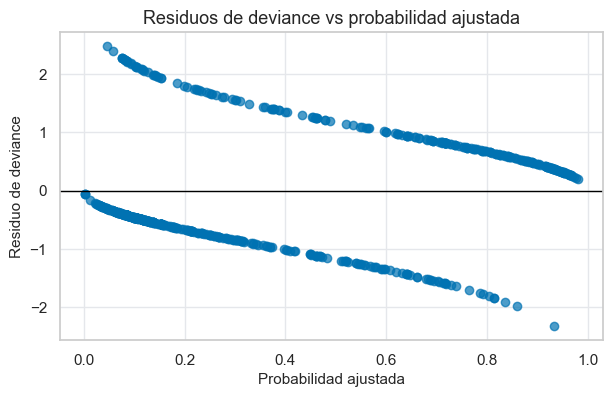

In [6]:
fitted = glm_result.fittedvalues
resid_deviance = glm_result.resid_deviance

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(fitted, resid_deviance, alpha=0.7)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Residuos de deviance vs probabilidad ajustada")
ax.set_xlabel("Probabilidad ajustada")
ax.set_ylabel("Residuo de deviance")
plt.show()


## 5. Coeficientes con intervalos de confianza

Los intervalos se interpretan en escala log-odds o, tras exponenciar, como odds ratios. Como siempre en datos observacionales, son asociaciones ajustadas por las variables incluidas, no efectos causales garantizados.


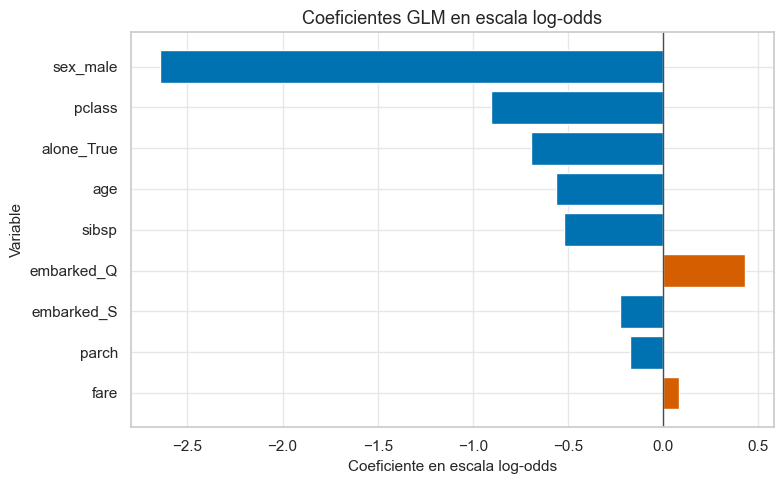

In [7]:
coef_no_intercept = glm_result.params.drop("const")
plot_coefficients(
    coef_no_intercept,
    coef_no_intercept.index,
    "Coeficientes GLM en escala log-odds",
)
plt.show()


## Resumen y conexión con la literatura

El enfoque GLM formaliza la regresión logística como caso binomial con enlace logit. Permite hablar de deviance, IRLS, errores estándar e intervalos de confianza, exactamente el lenguaje de Nelder y Wedderburn, McCullagh y Nelder, y Agresti.
